<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/AdaBoost_scratch_own_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [124]:
X,y = make_classification(n_features = 2,n_clusters_per_class=2,n_informative = 2,n_redundant= 0 ,n_samples = 100)

# Combine X and y into a single array with 3 columns
# X has shape (100, 2) and y has shape (100,)
# Reshape y to (100, 1) to concatenate horizontally
combined_data = np.hstack((X, y.reshape(-1, 1)))

df = pd.DataFrame(combined_data, columns = ['f1','f2','target'])

<Axes: >

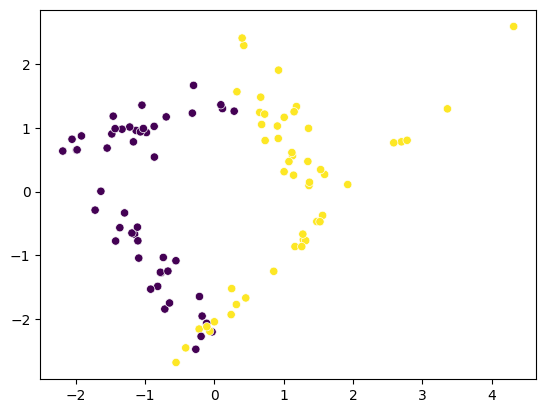

In [125]:
import seaborn as sns
sns.scatterplot(x = X[:,0],y = X[:,1],c = y)

In [126]:
#for the ada boost i have to start with the decision stump here how , we will do ?

df['weight'] = 1/df.shape[0]
df.head()

,f1,f2,target,weight
0,-2.054386,0.821087,0.0,0.01
1,0.732870,0.801064,1.0,0.01
2,-0.215050,-1.646953,0.0,0.01
3,1.163291,-0.863139,1.0,0.01
4,-1.151193,-0.669171,0.0,0.01


[Text(0.5, 0.75, 'x[0] <= 0.18\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.194\nsamples = 55\nvalue = [49, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.043\nsamples = 45\nvalue = [1, 44]'),
 Text(0.625, 0.5, '  False')]

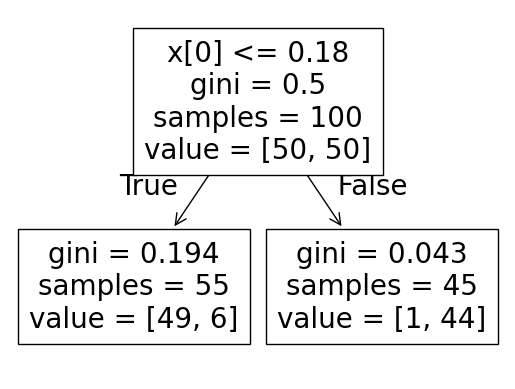

In [127]:
#DECISIONstump
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt1 = DecisionTreeClassifier(max_depth = 1)
dt1.fit(X,y)
plot_tree(dt1)

In [128]:
from sklearn.metrics import accuracy_score

In [129]:
accuracy_score(y, dt1.predict(X))

0.93

In [130]:
df['predict'] = dt1.predict(X)
df

,f1,f2,target,weight,predict
0,-2.054386,0.821087,0.0,0.01,0
1,0.732870,0.801064,1.0,0.01,1
2,-0.215050,-1.646953,0.0,0.01,0
3,1.163291,-0.863139,1.0,0.01,1
4,-1.151193,-0.669171,0.0,0.01,0
...,...,...,...,...,...
95,-1.110509,-0.558541,0.0,0.01,0
96,-0.554809,-1.085103,0.0,0.01,0
97,-1.432182,0.987609,0.0,0.01,0
98,-0.176765,-1.953682,0.0,0.01,0


In [131]:
error1 = (df[~(df['target'] == df['predict'])]['weight'].sum())
error1

np.float64(0.07)

In [132]:
# to get the alpha values here , we will apply the formula
alpha1 = (1/2) * np.log((1 - error1)/error1)

In [133]:
alpha1

np.float64(1.2933446720489712)

In [134]:
#now everything is not correct this , tree  kaeking some  mistakes , so , we will want to rectify those problems , by assigning the upsampling or the higherweights there easily , very easily

df

,f1,f2,target,weight,predict
0,-2.054386,0.821087,0.0,0.01,0
1,0.732870,0.801064,1.0,0.01,1
2,-0.215050,-1.646953,0.0,0.01,0
3,1.163291,-0.863139,1.0,0.01,1
4,-1.151193,-0.669171,0.0,0.01,0
...,...,...,...,...,...
95,-1.110509,-0.558541,0.0,0.01,0
96,-0.554809,-1.085103,0.0,0.01,0
97,-1.432182,0.987609,0.0,0.01,0
98,-0.176765,-1.953682,0.0,0.01,0


In [135]:
# Update weights for misclassified samples
df.loc[~(df['target'] == df['predict']), 'weight'] = df.loc[~(df['target'] == df['predict']), 'weight'] * np.exp(alpha1)

# Update weights for correctly classified samples
df.loc[(df['target'] == df['predict']), 'weight'] = df.loc[(df['target'] == df['predict']), 'weight'] * np.exp(-alpha1)

# Normalize the weights
df['weight'] = df['weight'] / df['weight'].sum()

In [136]:
df = df.drop(columns = 'predict')

In [142]:
np.cumsum(df['weight'].ravel())

/tmp/ipykernel_619/1025032676.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  np.cumsum(df['weight'].ravel())


array([0.00537634, 0.01075269, 0.01612903, 0.02150538, 0.02688172,
       0.03225806, 0.03763441, 0.04301075, 0.0483871 , 0.05376344,
       0.05913978, 0.06451613, 0.06989247, 0.07526882, 0.08064516,
       0.08602151, 0.09139785, 0.09677419, 0.10215054, 0.10752688,
       0.11290323, 0.11827957, 0.12365591, 0.12903226, 0.1344086 ,
       0.20583717, 0.21121352, 0.21658986, 0.22196621, 0.22734255,
       0.23271889, 0.23809524, 0.30952381, 0.31490015, 0.3202765 ,
       0.32565284, 0.33102919, 0.33640553, 0.34178187, 0.34715822,
       0.35253456, 0.35791091, 0.36328725, 0.36866359, 0.37403994,
       0.44546851, 0.45084485, 0.4562212 , 0.46159754, 0.46697389,
       0.47235023, 0.5437788 , 0.54915515, 0.55453149, 0.55990783,
       0.63133641, 0.63671275, 0.64208909, 0.64746544, 0.65284178,
       0.65821813, 0.66359447, 0.66897081, 0.67434716, 0.6797235 ,
       0.68509985, 0.69047619, 0.69585253, 0.70122888, 0.77265745,
       0.77803379, 0.78341014, 0.78878648, 0.79416283, 0.79953

In [144]:
def range_test():
  cumsum_weights = np.cumsum(df['weight'].to_numpy())
  ranges = []
  # Start from 0
  ranges.append(f"0.0 - {cumsum_weights[0]:.4f}")
  for i in range(len(cumsum_weights) - 1):
    ranges.append(f"{cumsum_weights[i]:.4f} - {cumsum_weights[i+1]:.4f}")
  return ranges

range_test()

['0.0 - 0.0054',
 '0.0054 - 0.0108',
 '0.0108 - 0.0161',
 '0.0161 - 0.0215',
 '0.0215 - 0.0269',
 '0.0269 - 0.0323',
 '0.0323 - 0.0376',
 '0.0376 - 0.0430',
 '0.0430 - 0.0484',
 '0.0484 - 0.0538',
 '0.0538 - 0.0591',
 '0.0591 - 0.0645',
 '0.0645 - 0.0699',
 '0.0699 - 0.0753',
 '0.0753 - 0.0806',
 '0.0806 - 0.0860',
 '0.0860 - 0.0914',
 '0.0914 - 0.0968',
 '0.0968 - 0.1022',
 '0.1022 - 0.1075',
 '0.1075 - 0.1129',
 '0.1129 - 0.1183',
 '0.1183 - 0.1237',
 '0.1237 - 0.1290',
 '0.1290 - 0.1344',
 '0.1344 - 0.2058',
 '0.2058 - 0.2112',
 '0.2112 - 0.2166',
 '0.2166 - 0.2220',
 '0.2220 - 0.2273',
 '0.2273 - 0.2327',
 '0.2327 - 0.2381',
 '0.2381 - 0.3095',
 '0.3095 - 0.3149',
 '0.3149 - 0.3203',
 '0.3203 - 0.3257',
 '0.3257 - 0.3310',
 '0.3310 - 0.3364',
 '0.3364 - 0.3418',
 '0.3418 - 0.3472',
 '0.3472 - 0.3525',
 '0.3525 - 0.3579',
 '0.3579 - 0.3633',
 '0.3633 - 0.3687',
 '0.3687 - 0.3740',
 '0.3740 - 0.4455',
 '0.4455 - 0.4508',
 '0.4508 - 0.4562',
 '0.4562 - 0.4616',
 '0.4616 - 0.4670',
 '0

In [149]:
df['range'] = pd.DataFrame(np.array(range_test()))

In [154]:
df['weight'].sort_values(ascending = False)

,weight
25,0.071429
32,0.071429
45,0.071429
51,0.071429
69,0.071429
...,...
95,0.005376
96,0.005376
97,0.005376
98,0.005376


In [156]:
arr = np.random.rand(100)

In [185]:
df['range'].str.split(" - ")[10]

['0.0538', '0.0591']

In [169]:
df['range'].str.split("-").str[1]

,range
0,0.0054
1,0.0108
2,0.0161
3,0.0215
4,0.0269
...,...
95,0.9785
96,0.9839
97,0.9892
98,0.9946


In [170]:
arr

array([0.15967107, 0.86938957, 0.51747224, 0.80523048, 0.09212285,
       0.63127665, 0.11050582, 0.08469531, 0.36992201, 0.86970029,
       0.48300968, 0.41790053, 0.52133307, 0.49767651, 0.36145264,
       0.0989332 , 0.04611056, 0.41227319, 0.97691856, 0.79970358,
       0.99029825, 0.68116179, 0.73554148, 0.1218498 , 0.25323095,
       0.23586199, 0.83882277, 0.65649424, 0.74627177, 0.24192402,
       0.75828937, 0.87556556, 0.84117756, 0.90978444, 0.53322075,
       0.63655633, 0.11909305, 0.95401489, 0.53730245, 0.40274342,
       0.74667847, 0.85468498, 0.16448253, 0.02890112, 0.96584871,
       0.23687217, 0.78526548, 0.18729852, 0.51482013, 0.64624693,
       0.95383844, 0.94653572, 0.99358323, 0.53174373, 0.82397754,
       0.12807592, 0.90582132, 0.2317498 , 0.90293366, 0.12792637,
       0.80062632, 0.67147454, 0.92984431, 0.94319705, 0.78341899,
       0.70153468, 0.21329094, 0.63001916, 0.98125859, 0.06526547,
       0.10825811, 0.66045437, 0.47819229, 0.69149828, 0.91691

In [188]:
for i in arr:
  # Convert to numpy array to iterate over the lists of [start, end]
  for j in df['range'].str.split(" - ").to_numpy():
    # j is a list like ['0.0', '0.0054']
    if i >= float(j[0]) and i <= float(j[1]):
      print(f"{i} falls in range {j[0]} - {j[1]}")
      break

0.15967107396259816 falls in range 0.1344 - 0.2058
0.869389571874376 falls in range 0.8641 - 0.8694
0.5174722371272332 falls in range 0.4724 - 0.5438
0.8052304783629508 falls in range 0.8049 - 0.8103
0.09212284705805729 falls in range 0.0914 - 0.0968
0.6312766493649974 falls in range 0.5599 - 0.6313
0.11050581860902076 falls in range 0.1075 - 0.1129
0.08469531096529836 falls in range 0.0806 - 0.0860
0.36992200911674844 falls in range 0.3687 - 0.3740
0.8697002938326377 falls in range 0.8694 - 0.8748
0.48300967648647075 falls in range 0.4724 - 0.5438
0.41790053175865693 falls in range 0.3740 - 0.4455
0.5213330706107545 falls in range 0.4724 - 0.5438
0.49767651161082327 falls in range 0.4724 - 0.5438
0.3614526403015532 falls in range 0.3579 - 0.3633
0.09893320373751535 falls in range 0.0968 - 0.1022
0.046110562328536386 falls in range 0.0430 - 0.0484
0.4122731898770233 falls in range 0.3740 - 0.4455
0.9769185553869868 falls in range 0.9731 - 0.9785
0.7997035825850812 falls in range 0.7995

In [189]:
new_rows = []

for val in arr:
    # Iterate through the DataFrame to find which range the random value falls into
    for idx, row in df.iterrows():
        range_parts = row['range'].split(" - ")
        start, end = float(range_parts[0]), float(range_parts[1])

        if start <= val <= end:
            new_rows.append(row)
            break

# Create the new DataFrame from the collected rows
df_new = pd.DataFrame(new_rows).reset_index(drop=True)

print(f"Created new dataframe with {len(df_new)} rows.")
display(df_new.head())

Created new dataframe with 100 rows.


,f1,f2,target,weight,range
0,0.285898,1.261658,0.0,0.071429,0.1344 - 0.2058
1,1.372676,0.146085,1.0,0.005376,0.8641 - 0.8694
2,-0.066949,-2.191378,1.0,0.071429,0.4724 - 0.5438
3,-0.779344,-1.266237,0.0,0.005376,0.8049 - 0.8103
4,1.283221,-0.754987,1.0,0.005376,0.0914 - 0.0968


# **Will make a class on this**

In [1]:
class Adaboost_UKD:
  pass